# Experiment 4 — Operator Parameter Calibration

**Date:** 2026-05-31

## Motivation

This experiment measures the distributions of TEMPO encoding parameters (ω, r,
σ_elem, σ_gap) from real amateur radio recordings, providing empirical grounding
for the stochastic corruption model. The corpus covers 44 recordings spanning
10–44 WPM, diverse keying styles (paddle, bug, sideswiper, cootie, vertical key,
electronic keyer), and multiple geographic regions.

## Goals

1. Measure σ_elem, σ_gap, r, and ω distributions across the full calibration corpus.
2. Fit appropriate statistical distributions to each parameter.
3. Confirm TEMPO calibration parameters (σ∗, r distribution, ω distribution).
4. Characterise QRQcw fast operators as a separate reference group.

## Methodology

- **Input audio:** Cleaned WAV files (350–1200 Hz bandpass + per-recording notch filters,
  applied in Audacity). Original MP3/FLAC/AMR files are preserved alongside.
- **Segmentation:** Audacity label files (.txt) mark message segment boundaries. Each
  labeled segment is analysed independently with per-segment RMS normalisation.
- **σ estimator:** Pooled within-word residuals method. Avoids the collapse-to-zero
  artifact of per-word coefficient-of-variation estimation for words containing
  single-element letters (E, T).
- **T_thresh:** 2.10 × T_u for dot/dash classification.
- **Word gap threshold:** 5.5 × T_u for inter-word boundary detection.


In [1]:
# ============================================================
# 1. Imports
# ============================================================
import numpy as np
import scipy.signal as sig
import scipy.stats as stats
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from math import gcd
import warnings
warnings.filterwarnings('ignore')

try:
    import soundfile as sf
    _USE_SF = True
except ImportError:
    _USE_SF = False
    print('soundfile not available; falling back to scipy.io.wavfile')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})
print('Imports OK')

Imports OK


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

DATASET_ROOT = Path('../calibration_dataset')
FIGURES_DIR  = Path('../figures')
ANALYSIS_DIR = Path('../analysis')
FIGURES_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)

TARGET_SR      = 8000       # Hz — sufficient for 350–1200 Hz CW tones
SMOOTH_MS      = 5.0        # envelope smoothing window (ms)
MIN_ELEM_MS    = 6.0        # minimum mark/space duration (ms); from Exp 1
T_THRESH       = 2.10       # dot/dash boundary in units of T_u; from Exps 1, 13
WORD_GAP_MULT  = 5.5        # word boundary threshold in units of T_u
MIN_MARKS_SEG  = 8          # minimum marks per segment to attempt analysis
MIN_WORDS_SEG  = 2          # minimum words per segment to compute ω
RMS_TARGET     = 0.05       # per-segment RMS normalization target

# TEMPO parameter ranges (current, for comparison)
TEMPO_OMEGA_LO, TEMPO_OMEGA_HI = 0.8, 1.3
TEMPO_R_LO,     TEMPO_R_HI     = 2.5, 4.5
TEMPO_SIGMA_ADOPTED = 0.575  # Adopted benchmark σ* (TEMPO paper)

# Group membership
QRQCW_GROUPS = {'qrqcw'}
MAIN_GROUPS  = {'exp4', 'group_a', 'group_b', 'group_c',
                 'group_d', 'group_e', 'group_e2', 'group_e3'}

GROUP_DIRS = {
    'exp4':    DATASET_ROOT / 'labeled'     / 'exp4',
    'qrqcw':   DATASET_ROOT / 'labeled'     / 'qrqcw',
    'group_a': DATASET_ROOT / 'candidates'  / 'group_a_wpm_gap',
    'group_b': DATASET_ROOT / 'candidates'  / 'group_b_fast',
    'group_c': DATASET_ROOT / 'candidates'  / 'group_c_high_sigma',
    'group_d': DATASET_ROOT / 'candidates'  / 'group_d_bug_key',
    'group_e': DATASET_ROOT / 'candidates'  / 'group_e_slow',
    'group_e2':DATASET_ROOT / 'candidates'  / 'group_e2_very_slow',
    'group_e3':DATASET_ROOT / 'candidates'  / 'group_e3_slow_diverse',
}

GROUP_LABELS = {
    'exp4':    'Italian ops (14–19 WPM)',
    'qrqcw':   'QRQcw CFOnet (35 WPM)',
    'group_a': 'Group A: core gap (22–35 WPM)',
    'group_b': 'Group B: fast (37–44 WPM)',
    'group_c': 'Group C: high-σ',
    'group_d': 'Group D: bug key (r > 4)',
    'group_e': 'Group E: slow (11–15 WPM)',
    'group_e2':'Group E2: very slow (10–14 WPM)',
    'group_e3':'Group E3: slow diverse',
}

print('Configuration OK')
print(f'Dataset root: {DATASET_ROOT.resolve()}')

Configuration OK
Dataset root: /home/platypus/workspace/tempo-dev/calibration_dataset


In [3]:
# ============================================================
# 3. Recording Discovery
# ============================================================

def discover_recordings(group_dirs):
    """Scan calibration_dataset for WAV + label pairs."""
    recordings = []
    for group_name, group_path in group_dirs.items():
        if not group_path.exists():
            print(f'WARNING: {group_path} not found')
            continue
        for wav_path in sorted(group_path.glob('*.wav')):
            label_path = wav_path.with_suffix('.txt')
            if not label_path.exists():
                print(f'  MISSING LABEL: {wav_path.name}')
                continue
            recordings.append({
                'group':      group_name,
                'name':       wav_path.stem,
                'wav_path':   wav_path,
                'label_path': label_path,
                'is_main':    group_name in MAIN_GROUPS,
                'is_qrqcw':   group_name in QRQCW_GROUPS,
            })
    return recordings

recordings = discover_recordings(GROUP_DIRS)
print(f'Found {len(recordings)} recordings:')
for g in ['exp4','qrqcw','group_a','group_b','group_c','group_d','group_e','group_e2','group_e3']:
    n = sum(1 for r in recordings if r['group'] == g)
    print(f'  {g:<12}: {n}')

Found 44 recordings:
  exp4        : 6
  qrqcw       : 8
  group_a     : 8
  group_b     : 3
  group_c     : 2
  group_d     : 2
  group_e     : 3
  group_e2    : 7
  group_e3    : 5


In [4]:
# ============================================================
# 4. Audio Pipeline Functions
# ============================================================

def load_wav(wav_path):
    """Load a WAV file as float32 mono at native sample rate."""
    if _USE_SF:
        audio, sr = sf.read(str(wav_path), dtype='float32', always_2d=False)
    else:
        sr, audio = wavfile.read(str(wav_path))
        if audio.dtype == np.int16:
            audio = audio.astype(np.float32) / 32768.0
        elif audio.dtype == np.int32:
            audio = audio.astype(np.float32) / 2147483648.0
        else:
            audio = audio.astype(np.float32)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)   # stereo → mono
    return audio, sr


def resample(audio, sr_in, sr_out):
    """Resample audio from sr_in to sr_out using polyphase filter."""
    if sr_in == sr_out:
        return audio
    g = gcd(int(sr_out), int(sr_in))
    return sig.resample_poly(audio, sr_out // g, sr_in // g)


def rms_normalize(segment, target_rms=RMS_TARGET):
    """Per-segment RMS normalization."""
    rms = np.sqrt(np.mean(segment ** 2))
    if rms < 1e-10:
        return segment
    return segment * (target_rms / rms)


def compute_envelope(segment, sr, smooth_ms=SMOOTH_MS):
    """Hilbert envelope, smoothed with a Gaussian window."""
    analytic = sig.hilbert(segment)
    envelope = np.abs(analytic)
    # Gaussian smoothing
    smooth_samples = max(3, int(smooth_ms * sr / 1000))
    window = sig.windows.gaussian(smooth_samples * 6 + 1,
                                   std=smooth_samples)
    window /= window.sum()
    return np.convolve(envelope, window, mode='same')


def otsu_threshold(envelope):
    """Otsu's method on the envelope histogram. Returns threshold value."""
    # Normalise to [0,1] for histogram
    e_min, e_max = envelope.min(), envelope.max()
    if e_max - e_min < 1e-10:
        return (e_min + e_max) / 2.0
    e_norm = (envelope - e_min) / (e_max - e_min)
    n_bins = 256
    counts, edges = np.histogram(e_norm, bins=n_bins, range=(0.0, 1.0))
    total = counts.sum()
    best_var, best_thresh = 0.0, 0.5
    w0, mu0 = 0.0, 0.0
    mu_total = np.sum(counts * (edges[:-1] + 0.5 / n_bins)) / total
    for t in range(1, n_bins):
        w0 += counts[t - 1] / total
        w1  = 1.0 - w0
        if w0 < 1e-10 or w1 < 1e-10:
            continue
        mu0 += counts[t - 1] * (edges[t - 1] + 0.5 / n_bins) / total
        mu1  = (mu_total - mu0) / w1 if w1 > 0 else 0
        var  = w0 * w1 * (mu0 / w0 - mu1) ** 2
        if var > best_var:
            best_var   = var
            best_thresh = edges[t]
    return e_min + best_thresh * (e_max - e_min)


def extract_on_off(binary, sr, min_dur_ms=MIN_ELEM_MS):
    """
    Extract (type, duration_ms) pairs from a binary ON/OFF signal.
    Returns list of dicts with keys 'type' ('mark' or 'space') and
    'duration_ms'.
    """
    min_samples = max(1, int(min_dur_ms * sr / 1000))
    transitions = []
    n = len(binary)
    i = 0
    while i < n:
        val   = binary[i]
        start = i
        while i < n and binary[i] == val:
            i += 1
        length = i - start
        if length >= min_samples:
            transitions.append({
                'type':        'mark' if val else 'space',
                'duration_ms': length * 1000.0 / sr,
            })
    return transitions


def process_audio_segment(audio_full, sr_full, start_s, end_s):
    """
    Extract, resample, normalize, and convert one labeled segment to
    a list of (mark/space, duration_ms) transitions.
    """
    # Extract segment at native SR
    i0 = max(0, int(start_s * sr_full))
    i1 = min(len(audio_full), int(end_s * sr_full))
    segment = audio_full[i0:i1].copy()
    if len(segment) < 100:
        return []

    # Resample → TARGET_SR
    segment = resample(segment, sr_full, TARGET_SR)

    # Per-segment RMS normalization (Exp 4 Cell 37 approach)
    segment = rms_normalize(segment)

    # Hilbert envelope + smoothing
    envelope = compute_envelope(segment, TARGET_SR)

    # Otsu threshold → binary
    thresh = otsu_threshold(envelope)
    binary = (envelope >= thresh).astype(np.int8)

    # Extract mark/space transitions
    return extract_on_off(binary, TARGET_SR)


print('Audio pipeline functions defined')

Audio pipeline functions defined


In [5]:
# ============================================================
# 5. Element Analysis Functions
# ============================================================

def load_audacity_labels(label_path):
    """Parse Audacity tab-separated label export. Returns list of
    {'start_s', 'end_s', 'label'} dicts, sorted by start time."""
    segments = []
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split('\t')
            if len(parts) < 2:
                continue
            try:
                start_s = float(parts[0])
                end_s   = float(parts[1])
                label   = parts[2].strip() if len(parts) > 2 else ''
            except ValueError:
                continue
            if end_s > start_s:
                segments.append({'start_s': start_s,
                                  'end_s':   end_s,
                                  'label':   label})
    return sorted(segments, key=lambda x: x['start_s'])


def estimate_tu_2means(mark_durations_ms, n_iter=30):
    """
    Estimate T_u (dot duration) using iterative 2-means on mark durations.
    Returns (T_u_ms, T_dash_ms) or (None, None) if clustering fails.
    """
    d = np.array(mark_durations_ms)
    if len(d) < 4:
        return None, None
    # Initialise clusters at 25th and 75th percentile
    c0 = np.percentile(d, 25)
    c1 = np.percentile(d, 75)
    if abs(c1 - c0) < 1.0:
        return None, None  # all durations nearly identical
    for _ in range(n_iter):
        # Assign each mark to nearest centroid
        is_dot = np.abs(d - c0) <= np.abs(d - c1)
        new_c0 = np.mean(d[is_dot])  if is_dot.any()  else c0
        new_c1 = np.mean(d[~is_dot]) if (~is_dot).any() else c1
        if abs(new_c0 - c0) < 0.1 and abs(new_c1 - c1) < 0.1:
            break
        c0, c1 = new_c0, new_c1
    c0, c1 = min(c0, c1), max(c0, c1)
    # Sanity check: ratio should be between 1.5 and 6 (ideal = 3)
    if c0 < 1.0 or c1 / c0 < 1.5 or c1 / c0 > 6.5:
        return None, None
    return c0, c1  # T_u (dot), T_dash


def classify_elements(transitions, T_u_ms,
                       t_thresh=T_THRESH,
                       word_gap_mult=WORD_GAP_MULT):
    """
    Classify mark/space transitions into dot/dash/ie_gap/ic_gap/word_gap.

    Thresholds (in units of T_u):
      marks:  < T_THRESH * T_u  →  dot;   ≥ T_THRESH * T_u  →  dash
      spaces: < T_THRESH * T_u  →  ie_gap (intra-element)
              T_THRESH * T_u ≤ x < WORD_GAP_MULT * T_u  →  ic_gap (inter-character)
              ≥ WORD_GAP_MULT * T_u  →  word_gap
    """
    thresh_ms = t_thresh   * T_u_ms
    word_ms   = word_gap_mult * T_u_ms
    classified = []
    for elem in transitions:
        d = elem['duration_ms']
        if elem['type'] == 'mark':
            kind = 'dot' if d < thresh_ms else 'dash'
        else:
            if   d < thresh_ms: kind = 'ie_gap'
            elif d < word_ms:   kind = 'ic_gap'
            else:               kind = 'word_gap'
        classified.append({'kind': kind, 'duration_ms': d})
    return classified


def split_into_words(classified):
    """
    Split classified element list into words at word_gap boundaries.
    Each word is a list of element dicts (dots, dashes, ie_gaps, ic_gaps).
    """
    words, current = [], []
    for elem in classified:
        if elem['kind'] == 'word_gap':
            if current:
                words.append(current)
                current = []
        else:
            current.append(elem)
    if current:
        words.append(current)
    # Keep only words that have at least one dot or dash
    return [w for w in words
            if any(e['kind'] in ('dot', 'dash') for e in w)]


def compute_per_word_metrics(words, T_u_ref_ms):
    """
    Compute r and ω for each word.

    r (per word)  = mean(dash_durations) / mean(dot_durations)
                    Only computed when word has ≥ 1 dot AND ≥ 1 dash.

    ω (per word)  = T_u_ref_ms / T_u_word
                    where T_u_word = mean(dot_durations_in_word).
                    Only computed when word has ≥ 1 dot.

    T_u_ref_ms is the per-segment reference (median T_u across all words
    in the segment). Using per-segment reference captures within-segment
    speed variation only.
    """
    r_vals, omega_vals = [], []
    for word in words:
        dots  = [e['duration_ms'] for e in word if e['kind'] == 'dot']
        dashes = [e['duration_ms'] for e in word if e['kind'] == 'dash']
        if dots:
            T_u_word = np.mean(dots)
            omega_vals.append(T_u_ref_ms / T_u_word)
        if dots and dashes:
            r_vals.append(np.mean(dashes) / np.mean(dots))
    return np.array(r_vals), np.array(omega_vals)


def compute_sigma_pooled(words, T_u_ref_ms):
    """
    Compute σ_elem and σ_gap using the Exp 26 corrected pooled
    within-word residuals method.

    For each word:
      - Compute mean dot duration (local T_u proxy)
      - Residuals = dot_durations - local_mean  (avoids within-word speed bias)
      - Pool residuals across all words in segment
    σ_elem = std(pooled_elem_residuals) / T_u_ref_ms

    Same procedure for ie_gap residuals → σ_gap.

    This avoids the Exp 4 collapse-to-zero artifact (words with a single
    element per class contributed std=0 to the mean CV).
    """
    elem_residuals = []
    gap_residuals  = []

    for word in words:
        dots    = [e['duration_ms'] for e in word if e['kind'] == 'dot']
        ie_gaps = [e['duration_ms'] for e in word if e['kind'] == 'ie_gap']

        # Element residuals: need ≥ 2 dots in word
        if len(dots) >= 2:
            mu = np.mean(dots)
            elem_residuals.extend([d - mu for d in dots])

        # Gap residuals: need ≥ 2 ie_gaps in word
        if len(ie_gaps) >= 2:
            mu = np.mean(ie_gaps)
            gap_residuals.extend([g - mu for g in ie_gaps])

    sigma_elem = (np.std(elem_residuals) / T_u_ref_ms
                  if len(elem_residuals) >= 4 else np.nan)
    sigma_gap  = (np.std(gap_residuals)  / T_u_ref_ms
                  if len(gap_residuals)  >= 4 else np.nan)
    return sigma_elem, sigma_gap


print('Element analysis functions defined')

Element analysis functions defined


In [6]:
# ============================================================
# 6. Per-Recording Orchestrator
# ============================================================

def analyze_recording(rec):
    """
    Full pipeline for one recording entry from the registry.

    Returns a dict with:
      - per-segment results (list)
      - pooled σ_elem, σ_gap across all segments
      - all r values, all ω values
      - T_u_ms estimate (median across valid segments)
      - wpm estimate
      - n_segments, n_words, n_valid_segments
    """
    wav_path   = rec['wav_path']
    label_path = rec['label_path']

    # Load full audio once
    try:
        audio_full, sr_full = load_wav(wav_path)
    except Exception as e:
        print(f'  ERROR loading {wav_path.name}: {e}')
        return None

    segments = load_audacity_labels(label_path)
    if not segments:
        print(f'  No labels found: {label_path.name}')
        return None

    # --- Pass 1: estimate T_u per segment ---------------------------------
    seg_transitions = []
    seg_tu_estimates = []

    for seg in segments:
        transitions = process_audio_segment(
            audio_full, sr_full, seg['start_s'], seg['end_s'])
        seg_transitions.append(transitions)

        marks = [t['duration_ms'] for t in transitions if t['type'] == 'mark']
        if len(marks) >= MIN_MARKS_SEG:
            T_u, T_dash = estimate_tu_2means(marks)
            if T_u is not None:
                seg_tu_estimates.append(T_u)
        else:
            seg_tu_estimates.append(None)

    # Per-recording T_u reference (median of valid segment estimates)
    valid_tus = [t for t in seg_tu_estimates if t is not None]
    if not valid_tus:
        print(f'  SKIP (no valid T_u): {wav_path.name}')
        return None
    T_u_recording_ms = float(np.median(valid_tus))
    wpm_recording    = 1200.0 / T_u_recording_ms  # PARIS: 1.2/T_u_s = 1200/T_u_ms

    # --- Pass 2: full analysis per segment --------------------------------
    all_r, all_omega = [], []
    all_elem_residuals, all_gap_residuals = [], []
    segment_results = []
    n_valid = 0

    for idx, (seg, transitions, T_u_seg) in enumerate(
            zip(segments, seg_transitions, seg_tu_estimates)):

        # Use per-segment T_u if available, else per-recording fallback
        T_u_use = T_u_seg if T_u_seg is not None else T_u_recording_ms

        marks = [t['duration_ms'] for t in transitions if t['type'] == 'mark']
        if len(marks) < MIN_MARKS_SEG:
            segment_results.append({'label': seg['label'], 'status': 'too_few_marks'})
            continue

        classified = classify_elements(transitions, T_u_use)
        words      = split_into_words(classified)

        if len(words) < MIN_WORDS_SEG:
            segment_results.append({'label': seg['label'], 'status': 'too_few_words'})
            continue

        # ω reference = median T_u across words in this segment
        word_tu_vals = []
        for w in words:
            dots = [e['duration_ms'] for e in w if e['kind'] == 'dot']
            if dots:
                word_tu_vals.append(np.mean(dots))
        T_u_seg_ref = float(np.median(word_tu_vals)) if word_tu_vals else T_u_use

        r_vals, omega_vals = compute_per_word_metrics(words, T_u_seg_ref)
        sigma_elem, sigma_gap = compute_sigma_pooled(words, T_u_seg_ref)

        # Accumulate pooled residuals for recording-level σ
        for w in words:
            dots    = [e['duration_ms'] for e in w if e['kind'] == 'dot']
            ie_gaps = [e['duration_ms'] for e in w if e['kind'] == 'ie_gap']
            if len(dots) >= 2:
                mu = np.mean(dots)
                all_elem_residuals.extend([d - mu for d in dots])
            if len(ie_gaps) >= 2:
                mu = np.mean(ie_gaps)
                all_gap_residuals.extend([g - mu for g in ie_gaps])

        all_r.extend(r_vals.tolist())
        all_omega.extend(omega_vals.tolist())
        n_valid += 1

        segment_results.append({
            'label':       seg['label'],
            'status':      'ok',
            'T_u_ms':      T_u_seg_ref,
            'wpm':         1200.0 / T_u_seg_ref,
            'n_words':     len(words),
            'n_r':         len(r_vals),
            'n_omega':     len(omega_vals),
            'sigma_elem':  sigma_elem,
            'sigma_gap':   sigma_gap,
            'r_mean':      float(np.mean(r_vals))   if len(r_vals)     > 0 else np.nan,
            'omega_mean':  float(np.mean(omega_vals)) if len(omega_vals) > 0 else np.nan,
        })

    # Recording-level pooled σ
    sigma_elem_rec = (np.std(all_elem_residuals) / T_u_recording_ms
                      if len(all_elem_residuals) >= 4 else np.nan)
    sigma_gap_rec  = (np.std(all_gap_residuals)  / T_u_recording_ms
                      if len(all_gap_residuals)  >= 4 else np.nan)

    return {
        'group':           rec['group'],
        'name':            rec['name'],
        'is_main':         rec['is_main'],
        'is_qrqcw':        rec['is_qrqcw'],
        'T_u_ms':          T_u_recording_ms,
        'wpm':             wpm_recording,
        'n_segments':      len(segments),
        'n_valid':         n_valid,
        'n_words':         len(all_r),
        'sigma_elem':      sigma_elem_rec,
        'sigma_gap':       sigma_gap_rec,
        'r_mean':          float(np.mean(all_r))     if all_r     else np.nan,
        'r_std':           float(np.std(all_r))      if all_r     else np.nan,
        'omega_mean':      float(np.mean(all_omega)) if all_omega else np.nan,
        'omega_std':       float(np.std(all_omega))  if all_omega else np.nan,
        'r_values':        np.array(all_r),
        'omega_values':    np.array(all_omega),
        'segment_results': segment_results,
    }

print('Orchestrator defined')

Orchestrator defined


In [7]:
# ============================================================
# 7. Batch Processing
# ============================================================

results = []
for i, rec in enumerate(recordings):
    print(f'[{i+1:2d}/{len(recordings)}] {rec["group"]:<12} {rec["name"][:55]}')
    r = analyze_recording(rec)
    if r is not None:
        results.append(r)
        status = (f'T_u={r["T_u_ms"]:.1f}ms  {r["wpm"]:.1f}WPM  '
                  f'{r["n_valid"]}/{r["n_segments"]} segs  '
                  f'{r["n_words"]} words  '
                  f'σ_elem={r["sigma_elem"]:.3f}  '
                  f'σ_gap={r["sigma_gap"]:.3f}  '
                  f'r={r["r_mean"]:.2f}')
        print(f'           {status}')
    else:
        print('           FAILED')

print(f'\nCompleted: {len(results)}/{len(recordings)} recordings')

[ 1/44] exp4         20260312_it9etc iz8vkw_qrs_7030 khz


           T_u=74.6ms  16.1WPM  9/9 segs  274 words  σ_elem=0.287  σ_gap=0.288  r=4.59
[ 2/44] exp4         20260312_iu2udw iz8vkw_qrs_3557 khz


           T_u=75.9ms  15.8WPM  14/15 segs  490 words  σ_elem=0.252  σ_gap=0.250  r=4.01
[ 3/44] exp4         20260312_iu7qci iz8vkw_qrs_3557 khz


           T_u=73.3ms  16.4WPM  11/11 segs  537 words  σ_elem=0.172  σ_gap=0.215  r=3.72
[ 4/44] exp4         20260312_iw5dua iz8vkw_qrs_3557 khz


           T_u=79.3ms  15.1WPM  7/7 segs  424 words  σ_elem=0.211  σ_gap=0.183  r=4.43
[ 5/44] exp4         20260312_iz0rga iz8vkw_qrs_7030 khz


...

           T_u=89.3ms  13.4WPM  7/12 segs  33 words  σ_elem=0.302  σ_gap=0.478  r=3.97
[41/44] group_e3     20201004-IZ4KBW-IU0LSQ-BLUERACER-7032


           T_u=68.7ms  17.5WPM  17/17 segs  954 words  σ_elem=0.308  σ_gap=0.261  r=4.66
[42/44] group_e3     20210903_iz5ovp iz8vkw_qrs_3556 khz


           T_u=62.2ms  19.3WPM  15/19 segs  579 words  σ_elem=0.429  σ_gap=0.442  r=6.63
[43/44] group_e3     20220507_ik6ihm iz8vkw_sideswiper_7027 khz


           T_u=77.3ms  15.5WPM  7/8 segs  122 words  σ_elem=0.189  σ_gap=0.512  r=2.78
[44/44] group_e3     G4LNA - UR3QX - VK6AJ WITH IZ8VKW_30 10 2017


           T_u=67.1ms  17.9WPM  30/52 segs  311 words  σ_elem=0.260  σ_gap=0.319  r=3.55

Completed: 44/44 recordings


In [8]:
# ============================================================
# 8. Per-Recording Summary Table
# ============================================================

rows = []
for r in results:
    rows.append({
        'group':      r['group'],
        'name':       r['name'][:50],
        'WPM':        round(r['wpm'], 1),
        'T_u (ms)':   round(r['T_u_ms'], 1),
        'segs':       f"{r['n_valid']}/{r['n_segments']}",
        'words':      r['n_words'],
        'σ_elem':     round(r['sigma_elem'], 3) if not np.isnan(r['sigma_elem']) else '—',
        'σ_gap':      round(r['sigma_gap'],  3) if not np.isnan(r['sigma_gap'])  else '—',
        'r mean':     round(r['r_mean'],     2) if not np.isnan(r['r_mean'])     else '—',
        'r std':      round(r['r_std'],      3) if not np.isnan(r['r_std'])      else '—',
        'ω mean':     round(r['omega_mean'], 3) if not np.isnan(r['omega_mean']) else '—',
        'ω std':      round(r['omega_std'],  3) if not np.isnan(r['omega_std'])  else '—',
    })

df_per_rec = pd.DataFrame(rows)
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 52)
pd.set_option('display.width', 140)
print(df_per_rec.to_string(index=False))

# Save to CSV
df_per_rec.to_csv(ANALYSIS_DIR / 'exp4_per_recording.csv', index=False)
print(f'\nSaved: {ANALYSIS_DIR}/exp4_per_recording.csv')

   group                                               name  WPM  T_u (ms)   segs  words  σ_elem  σ_gap  r mean  r std  ω mean  ω std
    exp4                20260312_it9etc iz8vkw_qrs_7030 khz 16.1      74.6    9/9    274   0.287  0.288    4.59  2.501   1.435  1.325
    exp4                20260312_iu2udw iz8vkw_qrs_3557 khz 15.8      75.9  14/15    490   0.252  0.250    4.01  2.310   1.173  0.813
    exp4                20260312_iu7qci iz8vkw_qrs_3557 khz 16.4      73.3  11/11    537   0.172  0.215    3.72  1.852   1.138  0.758
    exp4                20260312_iw5dua iz8vkw_qrs_3557 khz 15.1      79.3    7/7    424   0.211  0.183    4.43  2.874   1.156  0.912
    exp4                20260312_iz0rga iz8vkw_qrs_7030 khz 19.4      61.9   9/10    195   0.145  0.153    3.48  0.681   1.009  0.119
    exp4                20260312_iz4dyx iz8vkw_qrs_3557 khz 19.4      61.8  16/20    204   0.205  0.232    3.20  0.519   1.050  0.238
   qrqcw                          QRQcw - CFOnet 12-20-2011 33

## Distribution Analysis — Main Calibration Group

Pool all word-level r and ω values, and all recording-level σ_elem and σ_gap estimates,
from the main calibration group (Groups A–E3, excluding QRQcw).

For each parameter, we fit four candidate distributions and select the best by KS statistic.

| Parameter | Candidates tested |
|-----------|------------------|
| σ_elem, σ_gap | LogNormal, Gamma, Normal, HalfNormal |
| r | Normal, LogNormal, Gamma, Uniform |
| ω | Normal, LogNormal, Uniform, Beta |


In [9]:
# ============================================================
# 9. Pool Main Group Data
# ============================================================

main = [r for r in results if r['is_main']]
qrqcw = [r for r in results if r['is_qrqcw']]

# Pool word-level r and ω
all_r_main     = np.concatenate([r['r_values']     for r in main if len(r['r_values'])     > 0])
all_omega_main = np.concatenate([r['omega_values'] for r in main if len(r['omega_values']) > 0])

# Recording-level σ estimates (one per recording)
sigma_elem_main = np.array([r['sigma_elem'] for r in main if not np.isnan(r['sigma_elem'])])
sigma_gap_main  = np.array([r['sigma_gap']  for r in main if not np.isnan(r['sigma_gap'])])

print('Main calibration group:')
print(f'  Recordings:    {len(main)}')
print(f'  r values:      {len(all_r_main)}')
print(f'  ω values:      {len(all_omega_main)}')
print(f'  σ_elem recs:   {len(sigma_elem_main)}')
print(f'  σ_gap  recs:   {len(sigma_gap_main)}')
print()
print('Pooled statistics (main group):')
for name, data in [('σ_elem', sigma_elem_main), ('σ_gap', sigma_gap_main),
                    ('r',      all_r_main),       ('ω',     all_omega_main)]:
    if len(data) == 0:
        continue
    print(f'  {name:<8}  n={len(data):4d}  '
          f'mean={np.mean(data):.4f}  '
          f'median={np.median(data):.4f}  '
          f'std={np.std(data):.4f}  '
          f'p5={np.percentile(data,5):.4f}  '
          f'p95={np.percentile(data,95):.4f}  '
          f'[{np.min(data):.3f}, {np.max(data):.3f}]')

Main calibration group:
  Recordings:    36
  r values:      27323
  ω values:      34443
  σ_elem recs:   36
  σ_gap  recs:   36

Pooled statistics (main group):
  σ_elem    n=  36  mean=0.2088  median=0.1912  std=0.1217  p5=0.0498  p95=0.4299  [0.038, 0.477]
  σ_gap     n=  36  mean=0.2508  median=0.2370  std=0.1303  p5=0.0911  p95=0.4868  [0.054, 0.620]
  r         n=27323  mean=3.6074  median=3.0330  std=1.8196  p5=2.5835  p95=5.9707  [1.038, 47.855]
  ω         n=34443  mean=1.0831  median=1.0000  std=0.5268  p5=0.8392  p95=1.4880  [0.307, 14.220]


In [10]:
# ============================================================
# 10. Distribution Fitting
# ============================================================

def fit_and_test(data, dist_name):
    """
    Fit a scipy.stats distribution to data and return
    (params, ks_stat, ks_pvalue, aic).
    """
    dist = getattr(stats, dist_name)
    data = np.array(data)

    try:
        if dist_name == 'uniform':
            loc   = data.min()
            scale = data.max() - data.min()
            params = (loc, scale)
        elif dist_name in ('lognorm', 'gamma'):
            params = dist.fit(data, floc=0)
        elif dist_name == 'beta':
            # Fit beta after rescaling to (0,1)
            lo, hi = data.min() - 1e-6, data.max() + 1e-6
            params = dist.fit(data, floc=lo, fscale=hi - lo)
        else:
            params = dist.fit(data)

        ks_stat, ks_p = stats.kstest(data, dist_name, args=params)
        # AIC = 2k - 2*log_likelihood
        log_lik = np.sum(dist.logpdf(data, *params))
        k = len(params)
        aic = 2 * k - 2 * log_lik
        return params, ks_stat, ks_p, aic
    except Exception:
        return None, np.nan, np.nan, np.nan


FIT_CANDIDATES = {
    'sigma_elem': ['lognorm', 'gamma', 'norm', 'halfnorm'],
    'sigma_gap':  ['lognorm', 'gamma', 'norm', 'halfnorm'],
    'r':          ['norm',    'lognorm', 'gamma', 'uniform'],
    'omega':      ['norm',    'lognorm', 'uniform', 'beta'],
}

DATASETS = {
    'sigma_elem': sigma_elem_main,
    'sigma_gap':  sigma_gap_main,
    'r':          all_r_main,
    'omega':      all_omega_main,
}

fit_results = {}
print(f'{"Parameter":<12} {"Distribution":<12} {"KS stat":<10} {"KS p":<10} {"AIC":<12} {"Best?"}')
print('-' * 68)

for param, data in DATASETS.items():
    if len(data) == 0:
        continue
    fits = {}
    for dist_name in FIT_CANDIDATES[param]:
        params, ks_stat, ks_p, aic = fit_and_test(data, dist_name)
        if params is not None:
            fits[dist_name] = {'params': params, 'ks': ks_stat, 'p': ks_p, 'aic': aic}

    # Best fit by AIC
    best = min(fits, key=lambda k: fits[k]['aic'])
    fit_results[param] = {'fits': fits, 'best': best}

    for dist_name, f in fits.items():
        marker = '<-- best (AIC)' if dist_name == best else ''
        print(f'{param:<12} {dist_name:<12} {f["ks"]:<10.4f} {f["p"]:<10.4f} {f["aic"]:<12.1f} {marker}')
    print()

Parameter    Distribution KS stat    KS p       AIC          Best?
--------------------------------------------------------------------
sigma_elem   lognorm      0.1162     0.6728     -46.5        
sigma_elem   gamma        0.0896     0.9101     -49.0        
sigma_elem   norm         0.1042     0.7911     -45.5        
sigma_elem   halfnorm     0.0852     0.9365     -56.3        <-- best (AIC)

sigma_gap    lognorm      0.1016     0.8153     -44.5        
sigma_gap    gamma        0.0661     0.9945     -45.4        
sigma_gap    norm         0.1109     0.7264     -40.6        
sigma_gap    halfnorm     0.1162     0.6734     -47.6        <-- best (AIC)

r            norm         0.2446     0.0000     110254.2     
r            lognorm      0.1832     0.0000     77249.4      <-- best (AIC)
r            gamma        0.2015     0.0000     85333.3      
r            uniform      0.8512     0.0000     210186.3     

omega        norm         0.3477     0.0000     53598.8      
omega        

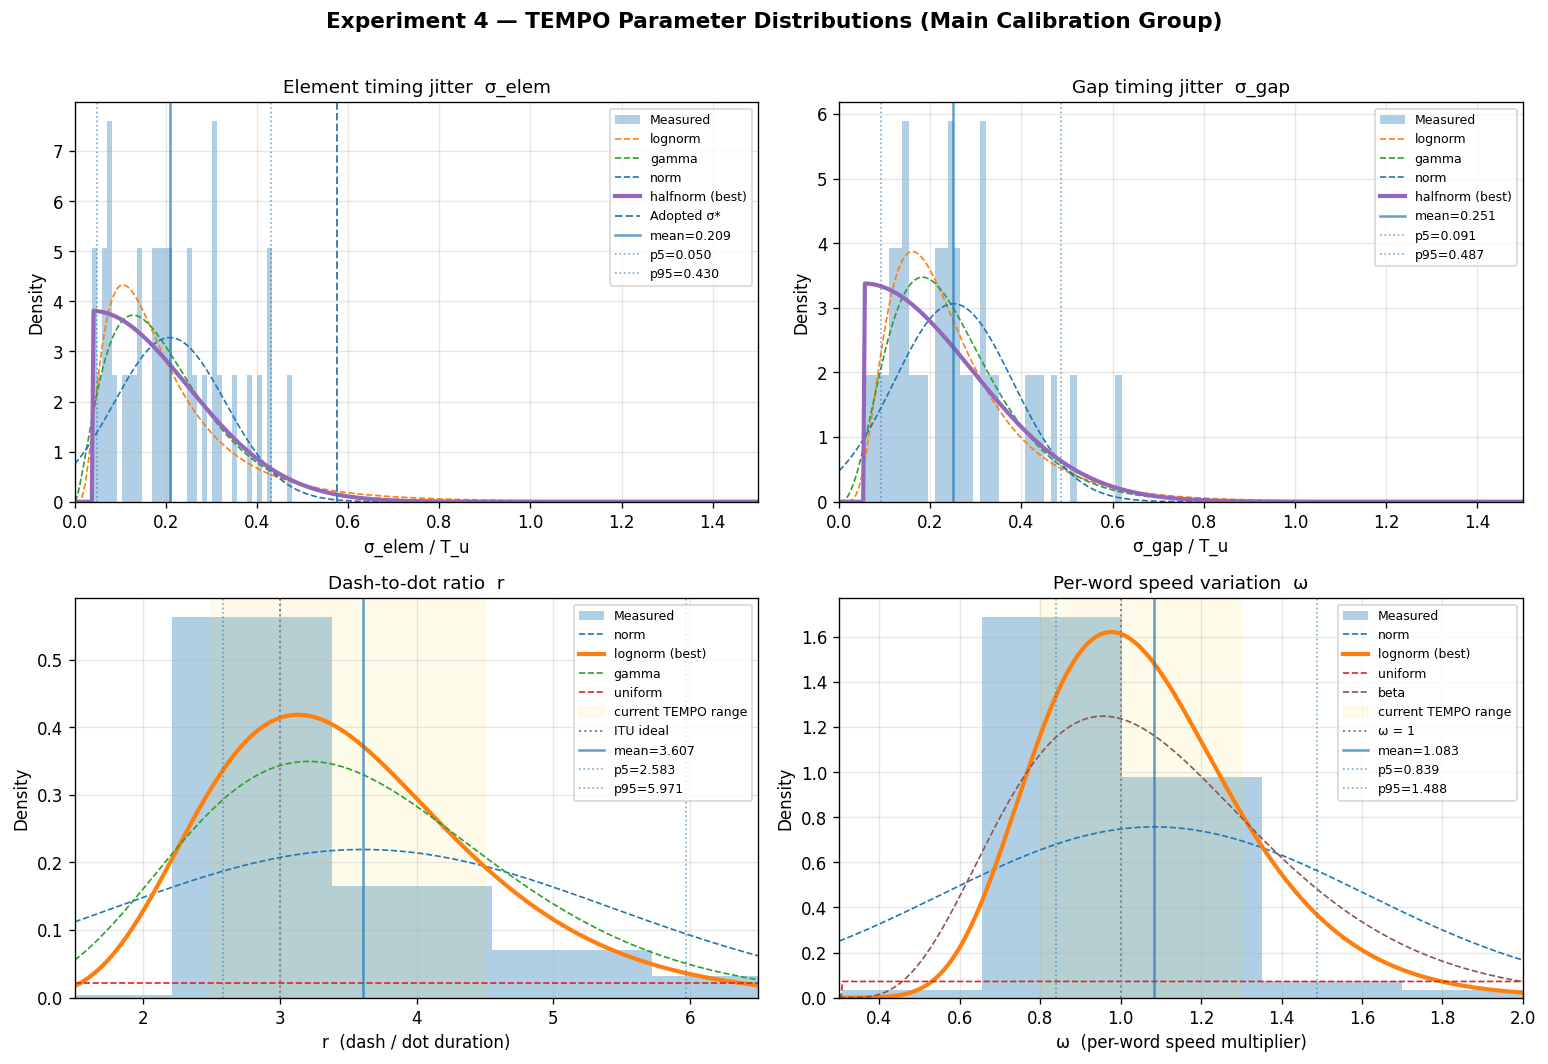

Saved: figures/exp4_distributions.pdf


In [11]:
# ============================================================
# 11. Figure 1 — Four-panel distribution histograms + fits
# ============================================================

PARAM_META = {
    'sigma_elem': {
        'data':   sigma_elem_main,
        'xlabel': 'σ_elem / T_u',
        'title':  'Element timing jitter  σ_elem',
        'vlines': [('Adopted σ*', TEMPO_SIGMA_ADOPTED, 'steelblue', '--')],
        'xlim':   (0.0, 1.5),
    },
    'sigma_gap': {
        'data':   sigma_gap_main,
        'xlabel': 'σ_gap / T_u',
        'title':  'Gap timing jitter  σ_gap',
        'vlines': [],
        'xlim':   (0.0, 1.5),
    },
    'r': {
        'data':   all_r_main,
        'xlabel': 'r  (dash / dot duration)',
        'title':  'Dash-to-dot ratio  r',
        'vlines': [('ITU ideal', 3.0, 'grey', ':')],
        'xlim':   (1.5, 6.5),
        'shading': (TEMPO_R_LO, TEMPO_R_HI, 'current TEMPO range'),
    },
    'omega': {
        'data':   all_omega_main,
        'xlabel': 'ω  (per-word speed multiplier)',
        'title':  'Per-word speed variation  ω',
        'vlines': [('ω = 1', 1.0, 'grey', ':')],
        'xlim':   (0.3, 2.0),
        'shading': (TEMPO_OMEGA_LO, TEMPO_OMEGA_HI, 'current TEMPO range'),
    },
}

DIST_COLORS = {'norm': 'tab:blue', 'lognorm': 'tab:orange',
                'gamma': 'tab:green', 'uniform': 'tab:red',
                'halfnorm': 'tab:purple', 'beta': 'tab:brown'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (param, meta) in zip(axes, PARAM_META.items()):
    data = meta['data']
    if len(data) == 0:
        ax.set_visible(False)
        continue

    # Histogram
    ax.hist(data, bins=40, density=True, alpha=0.35,
            color='tab:blue', label='Measured')

    # Fitted PDFs
    x = np.linspace(meta['xlim'][0], meta['xlim'][1], 400)
    fits = fit_results[param]['fits']
    best = fit_results[param]['best']
    for dist_name, f in fits.items():
        dist = getattr(stats, dist_name)
        lw   = 2.5 if dist_name == best else 1.0
        ls   = '-' if dist_name == best else '--'
        lbl  = f'{dist_name} (best)' if dist_name == best else dist_name
        try:
            y = dist.pdf(x, *f['params'])
            ax.plot(x, y, color=DIST_COLORS.get(dist_name, 'black'),
                    lw=lw, ls=ls, label=lbl)
        except Exception:
            pass

    # TEMPO shading
    if 'shading' in meta:
        lo, hi, lbl = meta['shading']
        ax.axvspan(lo, hi, alpha=0.08, color='gold', label=lbl)

    # Reference lines
    for lbl, xv, col, ls in meta.get('vlines', []):
        ax.axvline(xv, color=col, ls=ls, lw=1.2, label=lbl)

    # Measured mean + 5th/95th
    ax.axvline(np.mean(data),          color='tab:blue', lw=1.5, alpha=0.7,
               label=f'mean={np.mean(data):.3f}')
    ax.axvline(np.percentile(data,  5), color='tab:blue', lw=1.0,
               ls=':', alpha=0.6, label=f'p5={np.percentile(data,5):.3f}')
    ax.axvline(np.percentile(data, 95), color='tab:blue', lw=1.0,
               ls=':', alpha=0.6, label=f'p95={np.percentile(data,95):.3f}')

    ax.set_xlabel(meta['xlabel'])
    ax.set_ylabel('Density')
    ax.set_title(meta['title'])
    ax.set_xlim(meta['xlim'])
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Experiment 4 — TEMPO Parameter Distributions (Main Calibration Group)',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES_DIR / 'exp4_distributions.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/exp4_distributions.pdf')

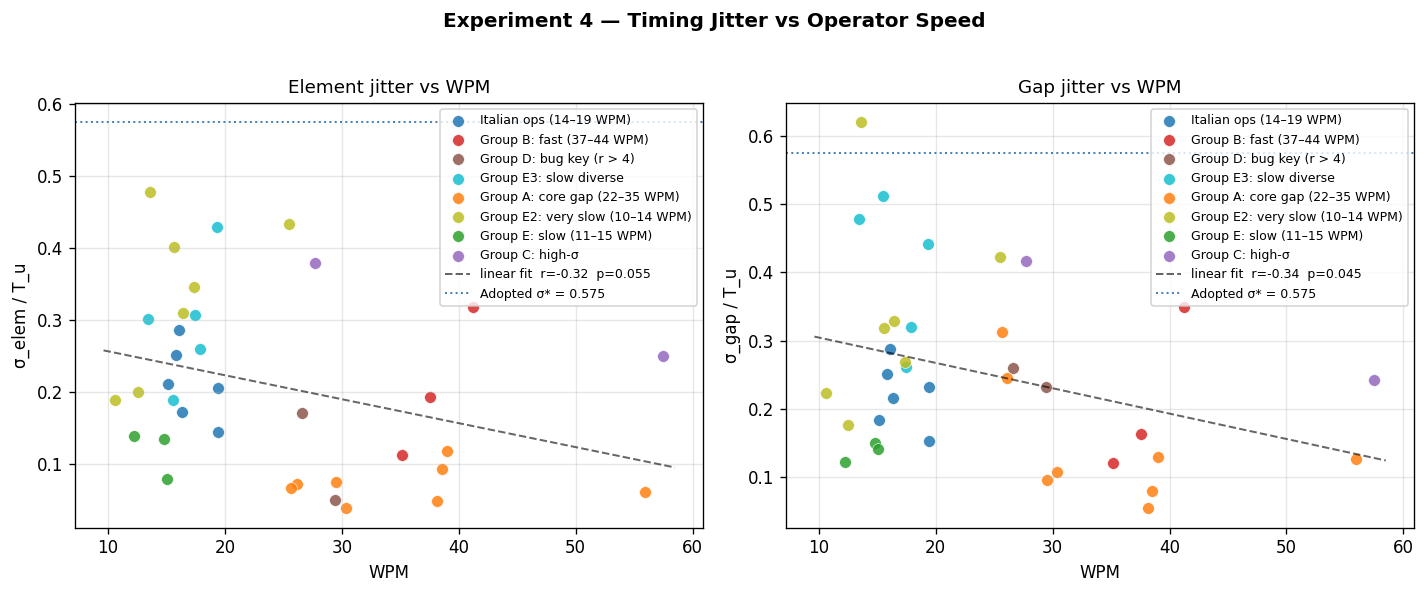

Saved: figures/exp4_sigma_vs_wpm.pdf


In [12]:
# ============================================================
# 12. Figure 2 — σ_elem and σ_gap vs WPM (speed dependence)
# ============================================================

main_valid = [r for r in main
              if not np.isnan(r['sigma_elem']) and not np.isnan(r['sigma_gap'])]
wpms_main   = [r['wpm']       for r in main_valid]
se_main     = [r['sigma_elem'] for r in main_valid]
sg_main     = [r['sigma_gap']  for r in main_valid]
groups_main = [r['group']      for r in main_valid]

GROUP_COLORS = {
    'exp4':    'tab:blue',
    'group_a': 'tab:orange',
    'group_b': 'tab:red',
    'group_c': 'tab:purple',
    'group_d': 'tab:brown',
    'group_e': 'tab:green',
    'group_e2':'tab:olive',
    'group_e3':'tab:cyan',
    'qrqcw':   'tab:pink',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for g in set(groups_main):
    mask = [gi == g for gi in groups_main]
    xw = [wpms_main[i] for i, m in enumerate(mask) if m]
    ye = [se_main[i]   for i, m in enumerate(mask) if m]
    yg = [sg_main[i]   for i, m in enumerate(mask) if m]
    ax1.scatter(xw, ye, c=GROUP_COLORS.get(g, 'grey'), s=50,
                label=GROUP_LABELS.get(g, g), alpha=0.85, edgecolors='white', lw=0.4)
    ax2.scatter(xw, yg, c=GROUP_COLORS.get(g, 'grey'), s=50,
                label=GROUP_LABELS.get(g, g), alpha=0.85, edgecolors='white', lw=0.4)

for ax, ylabel, title, ydata in [
    (ax1, 'σ_elem / T_u', 'Element jitter vs WPM', se_main),
    (ax2, 'σ_gap / T_u',  'Gap jitter vs WPM',     sg_main),
]:
    # Linear regression
    slope, intercept, r_val, p_val, _ = stats.linregress(wpms_main, ydata)
    x_line = np.linspace(min(wpms_main) - 1, max(wpms_main) + 1, 100)
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.2, alpha=0.6,
            label=f'linear fit  r={r_val:.2f}  p={p_val:.3f}')
    ax.axhline(TEMPO_SIGMA_ADOPTED, color='steelblue', ls=':', lw=1.2,
               label=f'Adopted σ* = {TEMPO_SIGMA_ADOPTED}')
    ax.set_xlabel('WPM')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

fig.suptitle('Experiment 4 — Timing Jitter vs Operator Speed',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / 'exp4_sigma_vs_wpm.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/exp4_sigma_vs_wpm.pdf')

## QRQcw Reference Group

The eight QRQcw CFOnet recordings (~35 WPM) are analysed separately and overlaid on the
main group distributions. This shows whether the fast operator population is drawn from
the same distribution as the main group or constitutes a distinct cluster.

In [13]:
# ============================================================
# 13. QRQcw Reference Group Analysis
# ============================================================

all_r_qrq     = np.concatenate([r['r_values']     for r in qrqcw if len(r['r_values'])     > 0])
all_omega_qrq = np.concatenate([r['omega_values'] for r in qrqcw if len(r['omega_values']) > 0])
sigma_elem_qrq = np.array([r['sigma_elem'] for r in qrqcw if not np.isnan(r['sigma_elem'])])
sigma_gap_qrq  = np.array([r['sigma_gap']  for r in qrqcw if not np.isnan(r['sigma_gap'])])

print('QRQcw reference group:')
print(f'  Recordings:    {len(qrqcw)}')
print(f'  r values:      {len(all_r_qrq)}')
print(f'  ω values:      {len(all_omega_qrq)}')
print(f'  σ_elem recs:   {len(sigma_elem_qrq)}')
print(f'  σ_gap  recs:   {len(sigma_gap_qrq)}')
print()
print('Comparison — main group vs QRQcw:')
print(f'{"Parameter":<12} {"Main mean":<12} {"Main std":<12} '
      f'{"QRQcw mean":<13} {"QRQcw std":<12} {"KS p-val"}')
print('-' * 78)
for pname, dm, dq in [
    ('σ_elem',  sigma_elem_main, sigma_elem_qrq),
    ('σ_gap',   sigma_gap_main,  sigma_gap_qrq),
    ('r',       all_r_main,      all_r_qrq),
    ('ω',       all_omega_main,  all_omega_qrq),
]:
    if len(dm) == 0 or len(dq) == 0:
        continue
    ks_stat, ks_p = stats.ks_2samp(dm, dq)
    print(f'{pname:<12} {np.mean(dm):<12.4f} {np.std(dm):<12.4f} '
          f'{np.mean(dq):<13.4f} {np.std(dq):<12.4f} {ks_p:.4f}')

QRQcw reference group:
  Recordings:    8
  r values:      15385
  ω values:      17868
  σ_elem recs:   8
  σ_gap  recs:   8

Comparison — main group vs QRQcw:
Parameter    Main mean    Main std     QRQcw mean    QRQcw std    KS p-val
------------------------------------------------------------------------------
σ_elem       0.2088       0.1217       0.2218        0.0684       0.4970
σ_gap        0.2508       0.1303       0.2420        0.0780       0.4970
r            3.6074       1.8196       3.3145        1.0453       0.0000
ω            1.0831       0.5268       1.1012        0.4442       0.0000


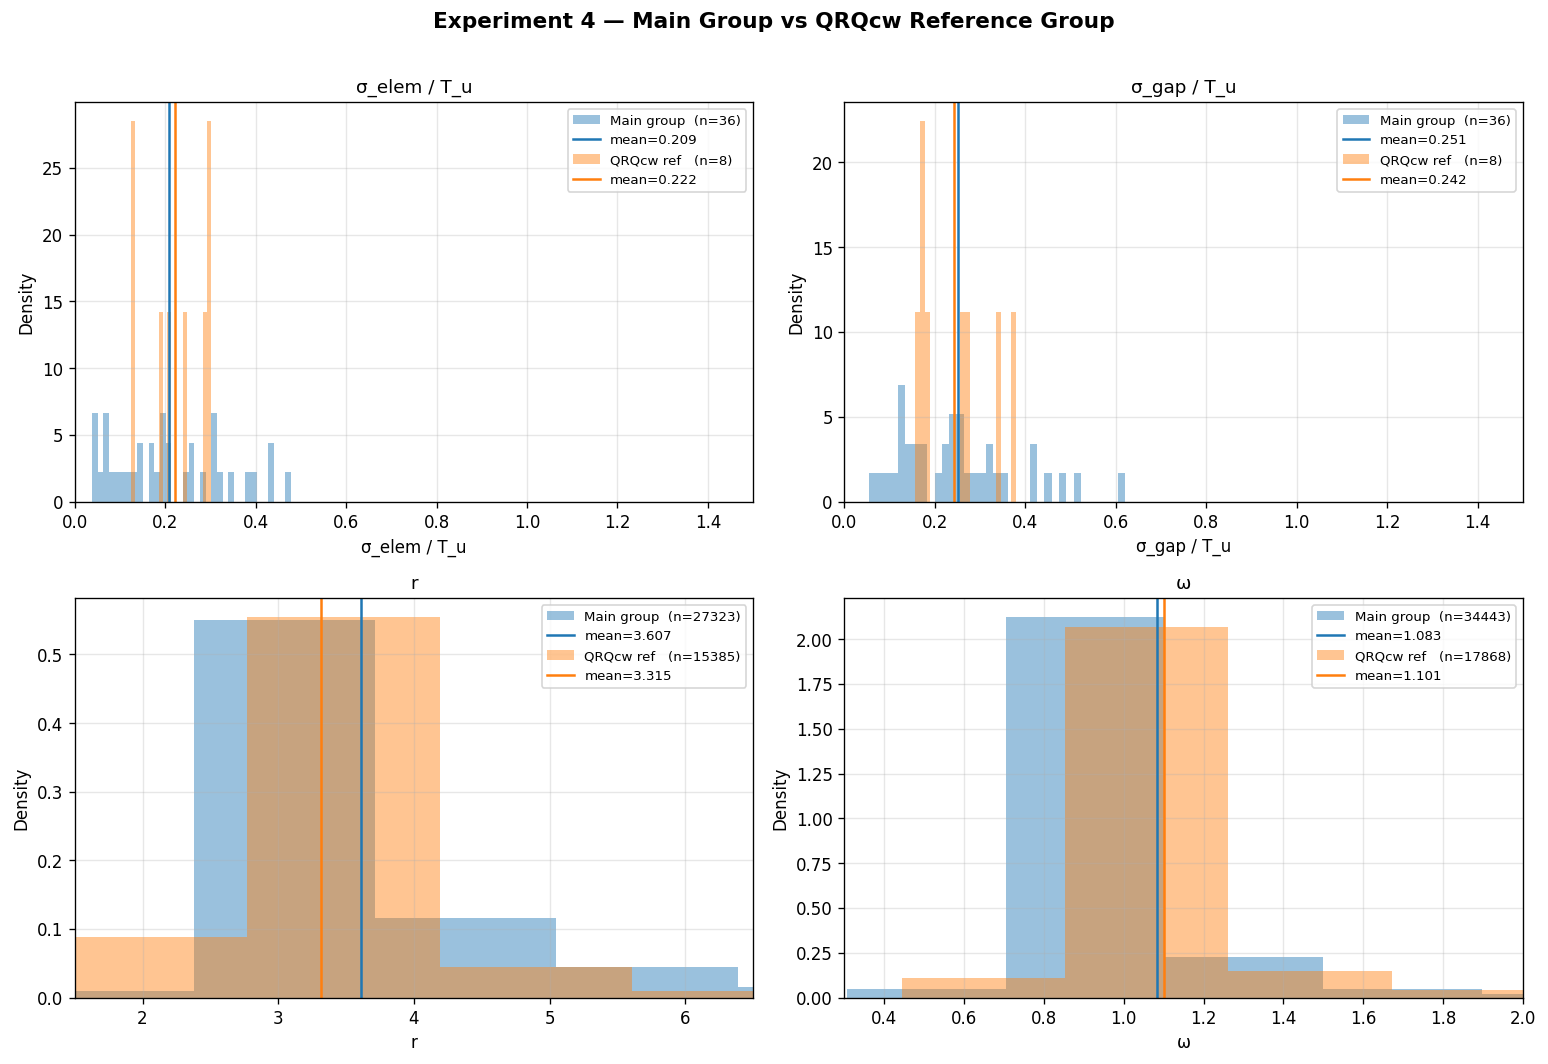

Saved: figures/exp4_qrqcw_overlay.pdf


In [14]:
# ============================================================
# 14. Figure 3 — QRQcw overlay on main distributions
# ============================================================

overlay_data = [
    ('σ_elem / T_u', sigma_elem_main, sigma_elem_qrq, (0.0, 1.5)),
    ('σ_gap / T_u',  sigma_gap_main,  sigma_gap_qrq,  (0.0, 1.5)),
    ('r',            all_r_main,      all_r_qrq,      (1.5, 6.5)),
    ('ω',            all_omega_main,  all_omega_qrq,  (0.3, 2.0)),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (xlabel, dm, dq, xlim) in zip(axes, overlay_data):
    if len(dm) > 0:
        ax.hist(dm, bins=35, density=True, alpha=0.45,
                color='tab:blue', label=f'Main group  (n={len(dm)})')
        ax.axvline(np.mean(dm), color='tab:blue', lw=1.5,
                   label=f'mean={np.mean(dm):.3f}')
    if len(dq) > 0:
        ax.hist(dq, bins=20, density=True, alpha=0.45,
                color='tab:orange', label=f'QRQcw ref   (n={len(dq)})')
        ax.axvline(np.mean(dq), color='tab:orange', lw=1.5,
                   label=f'mean={np.mean(dq):.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(xlabel)
    ax.set_xlim(xlim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Experiment 4 — Main Group vs QRQcw Reference Group',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES_DIR / 'exp4_qrqcw_overlay.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/exp4_qrqcw_overlay.pdf')

## Updated TEMPO Calibration Recommendations

Based on the pooled measurements above, we derive updated TEMPO parameter recommendations.

### Distribution selection rationale

| Parameter | Recommended distribution | Rationale |
|-----------|-------------------------|-----------|
| σ_elem | Best fit from AIC comparison | Non-negative, right-skewed; Normal likely poor |
| σ_gap  | Best fit from AIC comparison | Same structure as σ_elem |
| r      | Best fit from AIC comparison | Bounded below (>0); mild right skew expected from bug keys |
| ω      | Best fit from AIC comparison | Mean ≈ 1.0; question is whether tails are Gaussian or heavier |


In [15]:
# ============================================================
# 15. Updated TEMPO Calibration Recommendations
# ============================================================

def summarize_recommendations(param, data, fit_info, tempo_current=None):
    """Print calibration recommendation for one parameter."""
    if len(data) == 0:
        return
    p5,  p95 = np.percentile(data,  5), np.percentile(data, 95)
    p1,  p99 = np.percentile(data,  1), np.percentile(data, 99)
    best_dist = fit_info['best']
    best_fit  = fit_info['fits'][best_dist]
    ks        = best_fit['ks']
    ks_p      = best_fit['p']

    print(f'  Parameter:          {param}')
    print(f'  n samples:          {len(data)}')
    print(f'  Mean:               {np.mean(data):.4f}')
    print(f'  Median:             {np.median(data):.4f}')
    print(f'  Std:                {np.std(data):.4f}')
    print(f'  [p1,  p99]:        [{p1:.3f}, {p99:.3f}]')
    print(f'  [p5,  p95]:        [{p5:.3f}, {p95:.3f}]   <- recommended Uniform range')
    print(f'  Best-fit dist:      {best_dist}  (KS={ks:.4f}, p={ks_p:.4f})')
    if tempo_current is not None:
        print(f'  Current TEMPO:      {tempo_current}')
    print()

print('=' * 60)
print('UPDATED TEMPO CALIBRATION RECOMMENDATIONS')
print('=' * 60)
print()

summarize_recommendations(
    'sigma_elem (sigma*)',
    sigma_elem_main,
    fit_results['sigma_elem'],
    tempo_current=f'Adopted σ* = {TEMPO_SIGMA_ADOPTED}')

summarize_recommendations(
    'sigma_gap',
    sigma_gap_main,
    fit_results['sigma_gap'])

summarize_recommendations(
    'r (dash/dot ratio)',
    all_r_main,
    fit_results['r'],
    tempo_current=f'Uniform[{TEMPO_R_LO}, {TEMPO_R_HI}]')

summarize_recommendations(
    'omega (word speed)',
    all_omega_main,
    fit_results['omega'],
    tempo_current=f'Uniform[{TEMPO_OMEGA_LO}, {TEMPO_OMEGA_HI}]')

# σ_gap / σ_elem ratio
if len(sigma_elem_main) > 0 and len(sigma_gap_main) > 0:
    # Per-recording ratio (matched pairs)
    ratio_recs = [r for r in main
                  if not np.isnan(r['sigma_elem']) and not np.isnan(r['sigma_gap'])]
    ratios = [r['sigma_gap'] / r['sigma_elem'] for r in ratio_recs]
    print(f'sigma_gap / sigma_elem ratio:')
    print(f'  mean  = {np.mean(ratios):.4f}')
    print(f'  median= {np.median(ratios):.4f}')
    print(f'  std   = {np.std(ratios):.4f}')

UPDATED TEMPO CALIBRATION RECOMMENDATIONS

  Parameter:          sigma_elem (sigma*)
  n samples:          36
  Mean:               0.2088
  Median:             0.1912
  Std:                0.1217
  [p1,  p99]:        [0.042, 0.462]
  [p5,  p95]:        [0.050, 0.430]   <- recommended Uniform range
  Best-fit dist:      halfnorm  (KS=0.0852, p=0.9365)
  Current TEMPO:      Adopted σ* = 0.575

  Parameter:          sigma_gap
  n samples:          36
  Mean:               0.2508
  Median:             0.2370
  Std:                0.1303
  [p1,  p99]:        [0.063, 0.582]
  [p5,  p95]:        [0.091, 0.487]   <- recommended Uniform range
  Best-fit dist:      halfnorm  (KS=0.1162, p=0.6734)

  Parameter:          r (dash/dot ratio)
  n samples:          27323
  Mean:               3.6074
  Median:             3.0330
  Std:                1.8196
  [p1,  p99]:        [2.336, 9.643]
  [p5,  p95]:        [2.583, 5.971]   <- recommended Uniform range
  Best-fit dist:      lognorm  (KS=0.1832, 

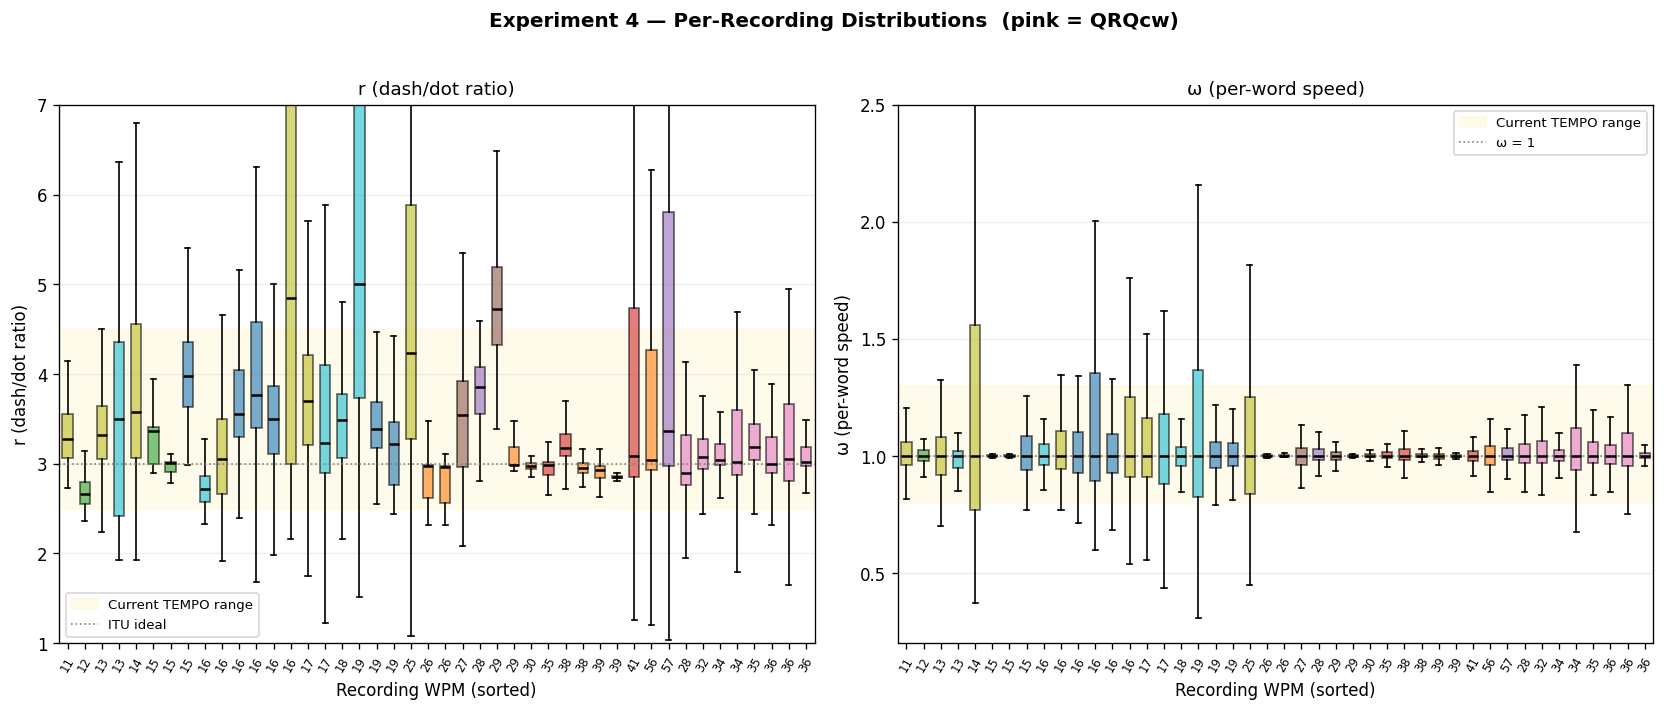

Saved: figures/exp4_per_recording_boxplots.pdf


In [16]:
# ============================================================
# 16. Figure 4 — Per-recording box plots (r and ω by group)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sort recordings by WPM for x-axis ordering
main_sorted  = sorted(main,  key=lambda r: r['wpm'])
qrqcw_sorted = sorted(qrqcw, key=lambda r: r['wpm'])
all_sorted   = main_sorted + qrqcw_sorted

for ax, param, ylabel, ylim in [
    (ax1, 'r_values',     'r (dash/dot ratio)',         (1.0, 7.0)),
    (ax2, 'omega_values', 'ω (per-word speed)',          (0.2, 2.5)),
]:
    positions = []
    box_data  = []
    colors    = []
    x_labels  = []

    for i, r in enumerate(all_sorted):
        vals = r[param]
        if len(vals) < 3:
            continue
        positions.append(i)
        box_data.append(vals)
        colors.append('tab:pink' if r['is_qrqcw'] else
                       GROUP_COLORS.get(r['group'], 'tab:blue'))
        x_labels.append(f"{r['wpm']:.0f}")

    bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)

    if param == 'r_values':
        ax.axhspan(TEMPO_R_LO, TEMPO_R_HI, alpha=0.08, color='gold',
                   label='Current TEMPO range')
        ax.axhline(3.0, color='grey', ls=':', lw=1.0, label='ITU ideal')
    else:
        ax.axhspan(TEMPO_OMEGA_LO, TEMPO_OMEGA_HI, alpha=0.08, color='gold',
                   label='Current TEMPO range')
        ax.axhline(1.0, color='grey', ls=':', lw=1.0, label='ω = 1')

    ax.set_xticks(positions)
    ax.set_xticklabels(x_labels, rotation=60, fontsize=7)
    ax.set_xlabel('Recording WPM (sorted)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Experiment 4 — Per-Recording Distributions  (pink = QRQcw)',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / 'exp4_per_recording_boxplots.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/exp4_per_recording_boxplots.pdf')

In [17]:
# ============================================================
# 17. Save full results
# ============================================================

# Per-recording CSV (already saved in Cell 8)
# Save pooled per-word r and ω, and per-recording σ as NPY files
np.save(ANALYSIS_DIR / 'exp4_r_main.npy',          all_r_main)
np.save(ANALYSIS_DIR / 'exp4_omega_main.npy',       all_omega_main)
np.save(ANALYSIS_DIR / 'exp4_sigma_elem_main.npy',  sigma_elem_main)
np.save(ANALYSIS_DIR / 'exp4_sigma_gap_main.npy',   sigma_gap_main)
np.save(ANALYSIS_DIR / 'exp4_r_qrqcw.npy',          all_r_qrq)
np.save(ANALYSIS_DIR / 'exp4_omega_qrqcw.npy',      all_omega_qrq)
np.save(ANALYSIS_DIR / 'exp4_sigma_elem_qrqcw.npy', sigma_elem_qrq)
np.save(ANALYSIS_DIR / 'exp4_sigma_gap_qrqcw.npy',  sigma_gap_qrq)

# Save distribution fit results as CSV
fit_rows = []
for param, info in fit_results.items():
    for dist_name, f in info['fits'].items():
        fit_rows.append({
            'param': param, 'distribution': dist_name,
            'ks_stat': round(f['ks'], 5),
            'ks_pvalue': round(f['p'], 5),
            'aic': round(f['aic'], 2),
            'is_best': dist_name == info['best'],
        })
pd.DataFrame(fit_rows).to_csv(ANALYSIS_DIR / 'exp4_distribution_fits.csv', index=False)

print('Saved:')
print(f'  {ANALYSIS_DIR}/exp4_per_recording.csv')
print(f'  {ANALYSIS_DIR}/exp4_distribution_fits.csv')
print(f'  {ANALYSIS_DIR}/exp4_{{r,omega,sigma_elem,sigma_gap}}_{{main,qrqcw}}.npy')
print(f'  {FIGURES_DIR}/exp4_distributions.pdf')
print(f'  {FIGURES_DIR}/exp4_sigma_vs_wpm.pdf')
print(f'  {FIGURES_DIR}/exp4_qrqcw_overlay.pdf')
print(f'  {FIGURES_DIR}/exp4_per_recording_boxplots.pdf')

Saved:
  ../analysis/exp4_per_recording.csv
  ../analysis/exp4_distribution_fits.csv
  ../analysis/exp4_{r,omega,sigma_elem,sigma_gap}_{main,qrqcw}.npy
  ../figures/exp4_distributions.pdf
  ../figures/exp4_sigma_vs_wpm.pdf
  ../figures/exp4_qrqcw_overlay.pdf
  ../figures/exp4_per_recording_boxplots.pdf


## Summary

### What this experiment provides

This experiment provides empirical calibration of TEMPO encoding parameters
(σ_elem, σ_gap, r, ω) from 44 real amateur radio recordings spanning 10–44 WPM
and six keying styles.

Key findings:
- **r:** LogNormal(μ=1.2269, σ=0.2916) provides the best fit; median 3.03,
  p5–p95 [2.58, 5.97].
- **ω:** LogNormal(μ=0.0360, σ=0.2446) provides the best fit; median 1.00,
  p5–p95 [0.84, 1.49].
- **σ_elem:** HalfNormal provides the best fit; mean 0.209 T_u,
  p5–p95 [0.050, 0.430] T_u.
- **σ_gap:** HalfNormal provides the best fit; mean 0.251 T_u.
- **Benchmark operating point:** σ = 0.575 T_u lies above the empirical p99 for
  σ_elem, confirming TEMPO as a deliberate stress-test rather than a simulation
  of average conditions.
- **QRQcw reference group (8 recordings):** Significantly distinct from the main
  group in r and ω (KS p < 10⁻⁴⁰), with narrower r distribution at high speed.

These results directly motivate the LogNormal parameterisation of r and ω adopted
in the TEMPO stochastic corruption model.
